# Tutorial | Single Cell RNA Sequence Analysis with Scanpy 📒🖋️

Special thanks to 👩🏼‍💻 **_Elif Duymaz Yılmaz, MSc._** for her contribution in preparing this tutorial.

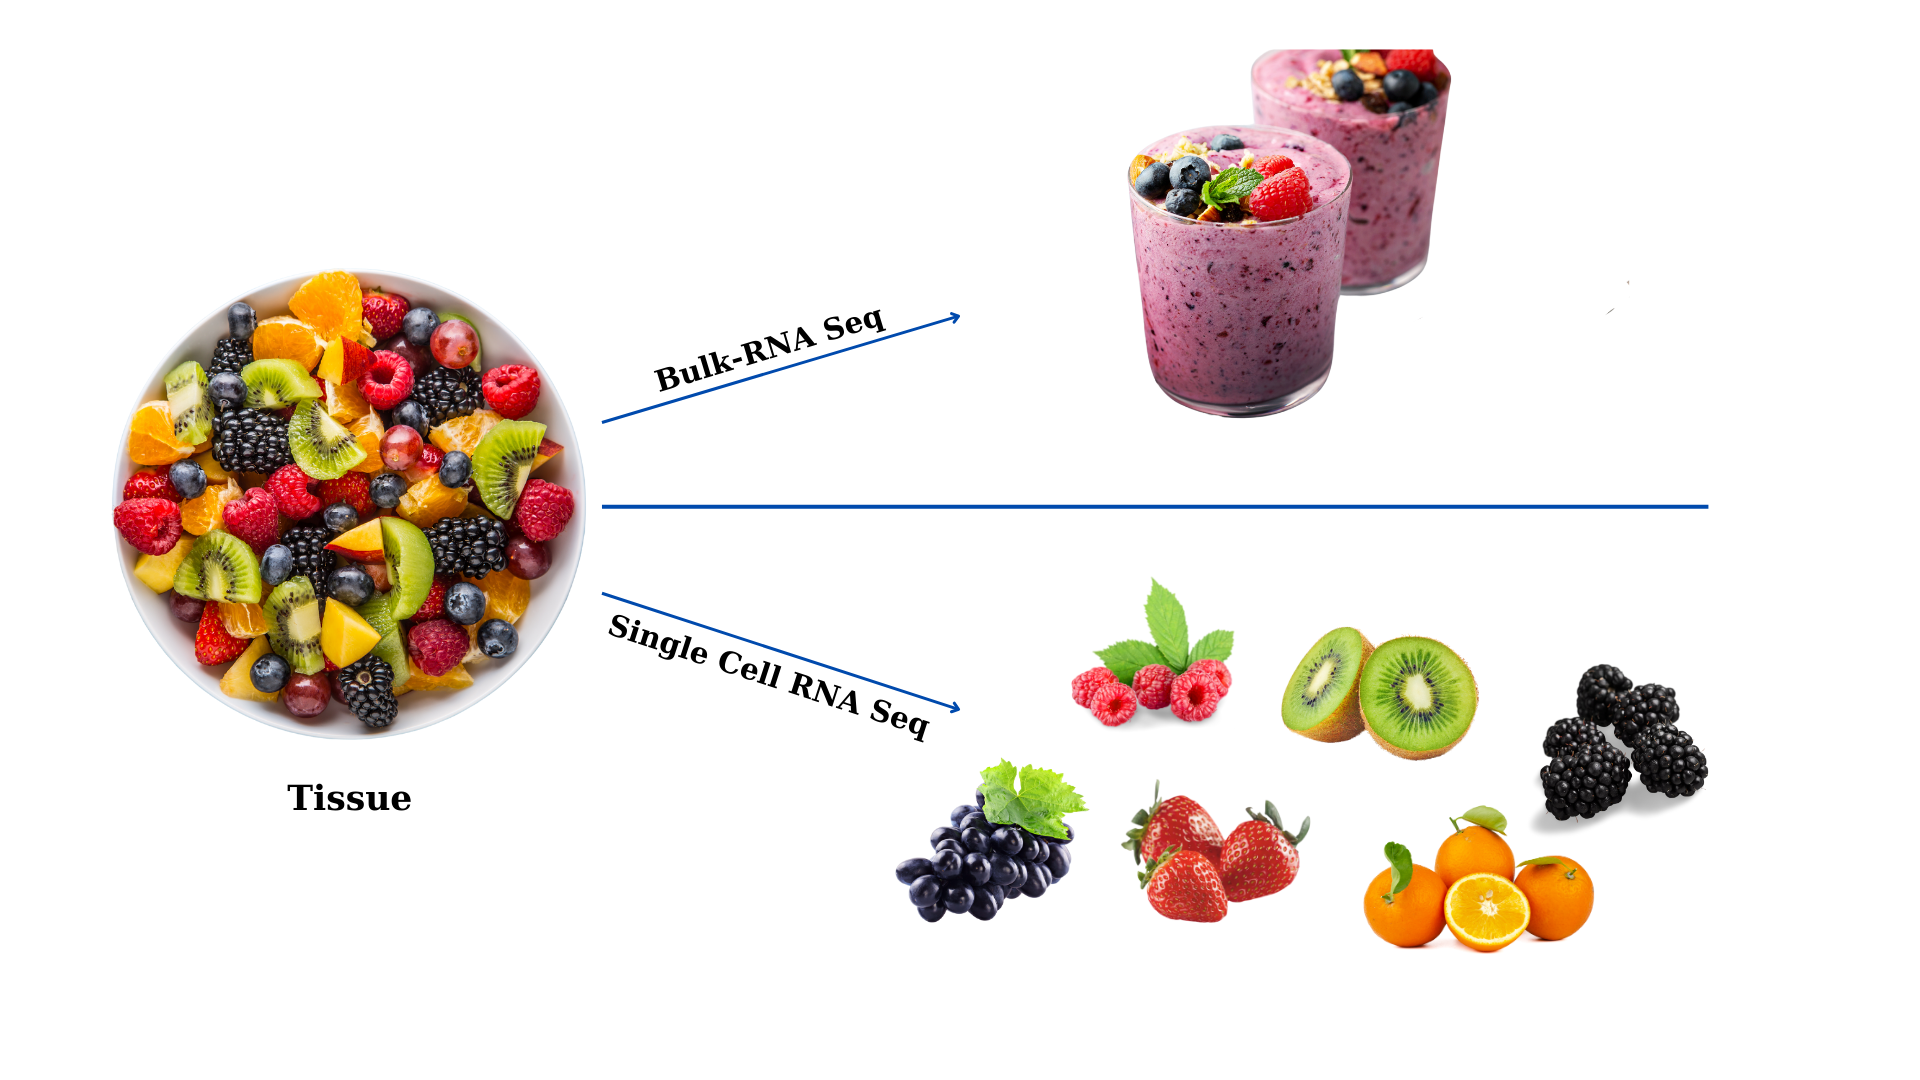

In [ ]:
from IPython.display import Image
Image("images/scRNAseq.png")

**Figure 1.** The differences between bulk RNA-seq and scRNA-seq ([Steinheuer ve ark. 2021](https://doi.org/10.1101/2021.04.02.438193))

You can access the workspace prepared to run the codes below as a Docker image on [**DockerHub**](https://hub.docker.com/r/elifduymaz/singlecell-workspace).
To perform the following operations, Docker must be installed on your computer. If Docker is not installed, you can follow the installation steps on the [Docker website](https://www.docker.com/) based on your device's requirements. For more information, you can review the [Docker document](https://docker-curriculum.com/).

#### ⏬ Download Dockerfile & Preparing the Workspace

In [ ]:
docker pull elifduymaz/singlecell-workspace

In [ ]:
docker run -p 8888:8888 elifduymaz/singlecell-workspace

<div style="border: 1px solid red; background-color: #f8d7da; padding: 10px; margin: 10px 0; border-radius: 5px;">
<b>🔔 📝 Important!</b> You need to run the above commands in your terminal. After that, you should see the address
<b>'http://localhost:8888/'</b> in your internet browser.
</div>


<div style="border: 1px solid orange; background-color: #fff3e6; padding: 10px; margin: 10px 0; border-radius: 5px;">
<b>🔖 Warning:</b> This guide is designed for single-cell RNA sequencing (scRNA-seq) analyses.
Basic knowledge of Python and Linux is required. Some of the commands below are written to be run on a Linux system, while others are intended to be executed in Python.
</div>

#### ⏬ Download Data

**fastq-dump**, is a tool included in the **[SRA Toolkit](https://github.com/ncbi/sra-tools/wiki/02.-Installing-SRA-Toolkit)**. You need to follow the necessary steps provided in the link to install it properly for your system. Once installed, you can download the raw SRR data (`.fastq.gz`) to your working directory.

In [ ]:
fastq-dump SRRXXXXXX

<div style="border: 2px dashed #0000FF; background-color: #e6f0ff; padding: 15px; margin: 10px 0; border-radius: 10px;">
<b>🦉 Information:</b> The PBMC dataset has been used for this guide. You can review it for more detailed information. ⏩
    <a href="https://www.10xgenomics.com/datasets/3-k-pbm-cs-from-a-healthy-donor-1-standard-1-1-0" target="_blank" style="color: #0000FF; text-decoration: underline;">PBMC3k</a>.
</div>

🔹 **wget** `https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_fastqs.tar`

``` markdown
Peripheral blood mononuclear cells (PBMCs) from a healthy donor (same donor as pbmc6k).
PBMCs are primary cells with relatively small amounts of RNA (~1pg RNA/cell).

- 2,700 cells detected
- Sequenced on Illumina NextSeq 500 with ~69,000 reads per cell
- 98bp read1 (transcript), 8bp I5 sample barcode, 14bp I7 GemCode barcode and 10bp read2 (UMI)
- Analysis run with --cells=3000
```

### 🔻 1. Processing Data and Counts (FASTQ ➡️ Count Matrix)

FASTQ files are data formats that contain raw sequencing data and serve as the foundation for bioinformatics analyses. To perform gene expression analysis, these raw data need to be processed and converted into gene expression counts. During this process, the number of transcripts sequenced for each gene in each cell is determined.

``` markdown
@SEQ_ID              # Information about the read's identifier

ATGGGTTGTCATTTAC     # The nucleotide sequence of the read

'+'                  # May contain additional information or simply be used as '+'

IIIIIIIII            # ASCII characters representing sequencing quality for each nucleotide    
```

<div style="border: 1px solid #4CAF50; background-color: #f9f9f9; padding: 10px; margin: 10px 0; border-radius: 5px;">
<b>Various tools are used for processing single-cell RNA sequencing (scRNA-seq) data and generating gene expression matrices. Below are some of the most commonly used tools and their features:</b>

- **[Cell Ranger](https://www.10xgenomics.com/support/software/cell-ranger/latest) (10x Genomics):**
Frequently used for analyzing data provided by the 10x Genomics platform. Cell Ranger takes sequencing data, aligns it to a reference genome, generates a gene expression matrix, and provides the results in matrix.mtx format. This tool is optimized to work seamlessly with the platform and offers a comprehensive workflow.

- **[STARsolo](https://github.com/alexdobin/STAR/blob/master/docs/STARsolo.md):**
A version of the popular STAR aligner specifically tailored for single-cell RNA-seq data. STARsolo aligns data to the reference genome and generates a gene expression matrix with high accuracy and speed. It stands out for its performance, especially when working with large datasets.

- **[Kallisto & BUStools](https://pachterlab.github.io/kallistobustools/tutorials/kb_getting_started/R/kb_intro_2_R/ ):**
Offering a pseudo-alignment-based approach, Kallisto & BUStools are recognized as fast and lightweight alternatives. These tools work at the transcript level rather than aligning to a reference genome and generate a gene expression count matrix, providing advantages in computational efficiency.
</div>

``` markdown
cellranger count --id=sample_name \
                 --transcriptome=/path/to/refdata-gex-GRCh38-2020-A \
                 --fastqs=/path/to/fastq_directory \
                 --sample=sample_name
```

<div style="border: 1px solid red; background-color: #f8d7da; padding: 10px; margin: 10px 0; border-radius: 5px;">
<b>🔔 📝 Important!</b> Processing large datasets typically requires high computing power and performance. The dataset we have is 18 GB in size, and working with data of this size requires a specific system capacity.
</div>


**Therefore, as an alternative option, you can use the following commands to access the processed results without the need for high processing power.**

In [4]:
!mkdir -p data
!curl https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz -o data/pbmc3k_filtered_gene_bc_matrices.tar.gz

!cd data; tar -xzf pbmc3k_filtered_gene_bc_matrices.tar.gz
!mkdir -p write

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7443k  100 7443k    0     0  16.7M      0 --:--:-- --:--:-- --:--:-- 16.7M


### 🔻 2. Converting Count Matrix to Anndata Format (Count Matrix ➡️ Anndata)
Count matrices obtained from tools like Cell Ranger or STARsolo typically include `matrix.mtx`, `features.tsv` and `barcodes.tsv` files. We can use `scanpy` to convert these files into the`.h5ad` format.

In [1]:
# Python libraries installation command
!pip install scanpy anndata scikit-learn matplotlib seaborn igraph

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.7/142.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 3.6 MB/s eta 0:00:00
  Created wheel for session-info: filename=session_info-1.0.0-py3-none-any.whl size=8023 sha256=c61ac428b34a4df971df0fa0e96c47bff67c603cc1b38b7136b295acd5a36afd
  Stored in directory: /root/.cache/pip/wheels/4e/56/35/a748fc57279a4b84d0b332879445fed1ad8478e7257986b015
Successfully built session-info


In [2]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

##### 🔹 **Load the Count Matrix**

In [5]:
adata = sc.read_10x_mtx(
    './data/filtered_gene_bc_matrices/hg19/',
    var_names='gene_symbols',
    cache=True
)

In [6]:
adata.X

<2700x32738 sparse matrix of type '<class 'numpy.float32'>'
	with 2286884 stored elements in Compressed Sparse Column format>

##### 🔹 **Save the data as `.h5ad`**

In [7]:
adata.write('./data/pbmc3k_adata.h5ad')

In [8]:
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

At this stage, we create an Anndata object containing gene expression counts for each cell. The **`.h5ad`** format is versatile, as it can store additional information about cells and genes along with the count data, enabling faster and more efficient analysis.

### 🔻 3. Adding Cell and Gene Information (Metadata Integration)

The `.h5ad` format is also suitable for adding additional information about cells or genes. At this stage, you can include cell and gene attributes (e.g., cell conditions, cell types, or quality metrics) in the AnnData object.

``` markdown
adata.obs['condition'] = ['control', 'treated', ...]  # Add cell info
adata.var['gene_length'] = [1000, 2000, ...]          # Add gene info
```

``` markdown
adata.write('pbmc3k_adata_version2.h5ad')  # saving to the current directory
```

Up to this point, the processed steps can be directly used for our guide. If you wish, you can continue working on the object you created.
In this case, when you need to read the `Anndata` object from its directory:

```markdown
adata = sc.read_h5ad("/path/pbmc3k_adata_version2.h5ad")

#The 'path' section should specify the directory where the file is located.
```

## Preprocess

Across all cells, we can visualize the genes with the highest count ratio in each cell as follows. This visualization can help you quickly identify abnormalities or unexpected patterns in the raw data. (Optional)

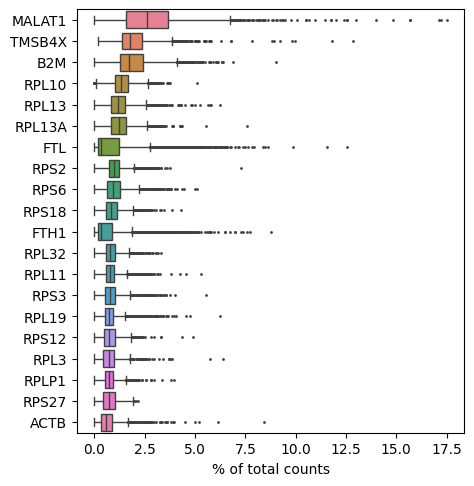

In [9]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [10]:
adata.n_vars

32738

In [11]:
adata.n_obs

2700

In [12]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [13]:
adata.n_obs

2700

In [14]:
adata.n_vars

13714

**19024 genes**, were filtered out as they were detected in fewer than **3 cells**.

### 🔻 4. Assessing Data Quality and Mitochondrial Filtering

🔹 **When evaluating cell quality, it is important to filter out low-quality cells. Cells with high expression levels of mitochondrial genes should be particularly considered in this context.**

High levels of mitochondrial gene expression often indicate low-quality cells; this could be due to the loss of cytoplasmic RNA in cells that have compromised membranes. The reason for this may be that mitochondria are larger than individual transcript molecules and are less affected by membrane ruptures. The `pp.calculate_qc_metrics` unction is used to efficiently calculate such metrics:

In [15]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(
    adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

Violin plot of some calculated quality metrics:

- Number of genes expressed in the count matrix,
- Total count per cell,
- Percentage of counts from mitochondrial genes.

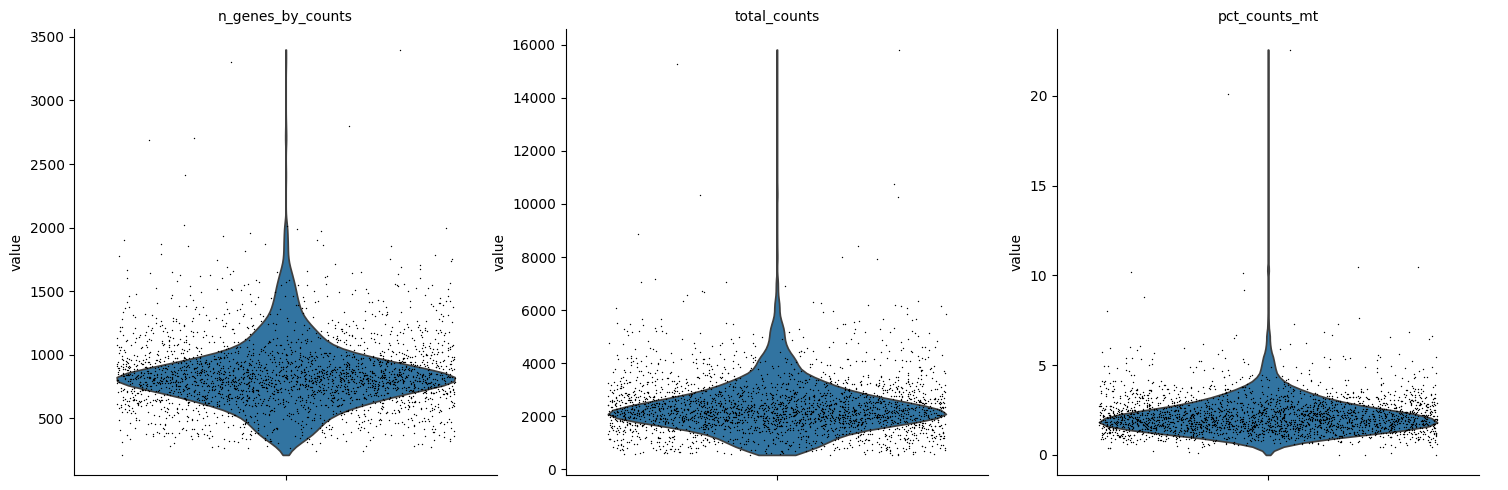

In [16]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

Cells with excessively high expression of mitochondrial genes or very high total read counts should be excluded from the analysis according to quality control criteria.

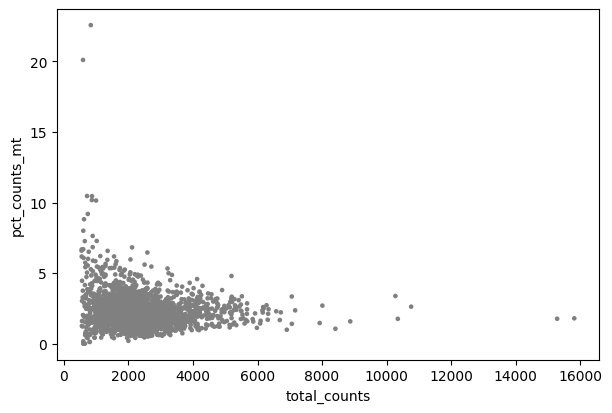

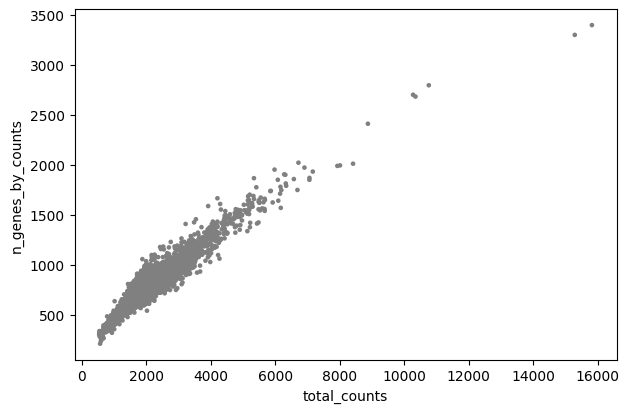

In [17]:
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

We can filter by splitting the tables of the`Anndata` object.

In [18]:
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()

By normalizing the total count data matrix to 10,000 reads per cell (scaling according to library size), we ensure that the counts become comparable, allowing for accurate assessment of biological variation between cells. This process enables the analysis of differences in total counts across cells to be based on biological changes rather than technical variation.

In [19]:
sc.pp.normalize_total(adata, target_sum=1e4)

In numerical data such as gene expression data, the data should be log-transformed to make the distribution more uniform and bring extreme outliers with large values into a more manageable range.

In [20]:
sc.pp.log1p(adata)

It is important to identify genes that best represent biologically meaningful variation and differentiation between cells. These genes typically provide better insights into biological processes, such as cellular differentiation, differences between cell types, or responses.

In [21]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

'''
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]
'''

'\nsc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=2000)\nadata = adata[:, adata.var.highly_variable]\n'

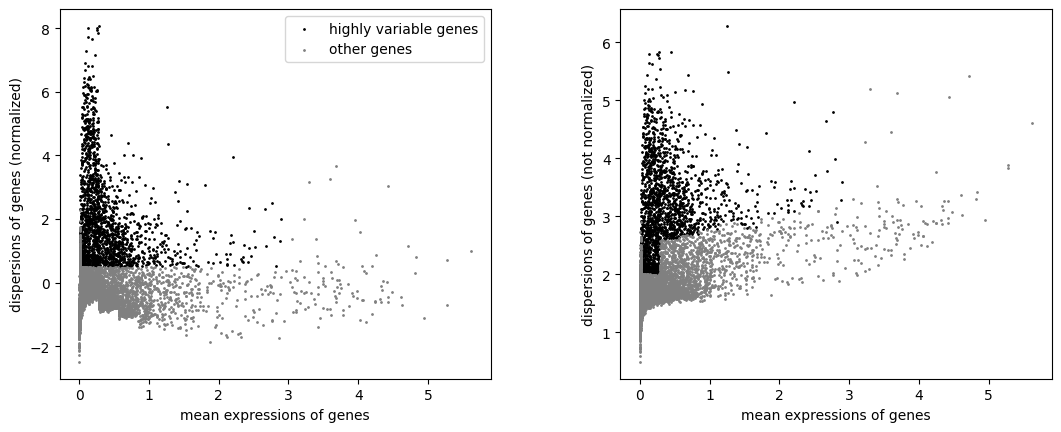

In [22]:
sc.pl.highly_variable_genes(adata)

We update the`.raw` attribute of the `AnnData` object with the raw gene expression data that has been normalized and log-transformed for future differential testing and gene expression visualizations.

🔹 This process is used to fix the current state of the `AnnData` object. If you want to revert to the original data after performing normalization or other processing, you can use the `.raw.to_adata()` method.

In [23]:
adata.raw = adata

##### Here, to detect biologically meaningful variation, we should remove genes with low or stable expression levels that show low variability from the analysis.

In [24]:
adata = adata[:, adata.var.highly_variable]

A **regression** process is performed to remove technical or biological effects, such as the total RNA count per cell `(total_counts)` and the percentage of mitochondrial gene expression `(pct_counts_mt)`, from the expression data.

In [25]:
sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])

In this process, all gene expressions are normalized and scaled to unit variance. Normalization and standardization align the different measurement scales of gene expressions. If the standardized z-score of a gene exceeds 10, the value is clipped to 10. This helps mitigate the effect of extreme outliers and ensures a more balanced analysis.

In [26]:
sc.pp.scale(adata, max_value=10)

## Analysis and Graphs

### 🔻 5. Principal Component Analysis

Principal Component Analysis *(PCA)* ([Pedregosa et al., 2011](https://dl.acm.org/doi/10.5555/1953048.2078195))  is a statistical method used to identify the principal axes of variation in high-dimensional data and reduce the dimensionality of the data. This technique helps preserve biological signals while minimizing technical noise. The `sc.tl.pca`  function performs PCA, and the `svd_solver="arpack"` parameter uses a mathematical algorithm optimized for large datasets. After performing PCA, the first components can be used for analysis, and these components often reflect cellular types or other biological variations.

In [27]:
sc.tl.pca(adata, svd_solver="arpack")

⭐ If desired, you can visualize the top 10 genes in PC1. # Optional

In [28]:
pc1_loadings = adata.varm['PCs'][:, 0]
genes = adata.var_names
pc1_genes = pd.DataFrame({'genes': genes, 'loadings': pc1_loadings})
top_pc1_genes = pc1_genes.sort_values('loadings', ascending=False).head(10)
print(top_pc1_genes)


       genes  loadings
1583    CST3  0.157474
1700  TYROBP  0.146447
894     FCN1  0.146411
588     LST1  0.145450
590     AIF1  0.145025
119   S100A8  0.143476
1818    TYMP  0.138734
1795  LGALS2  0.137575
145   FCER1G  0.133048
1797  LGALS1  0.129566


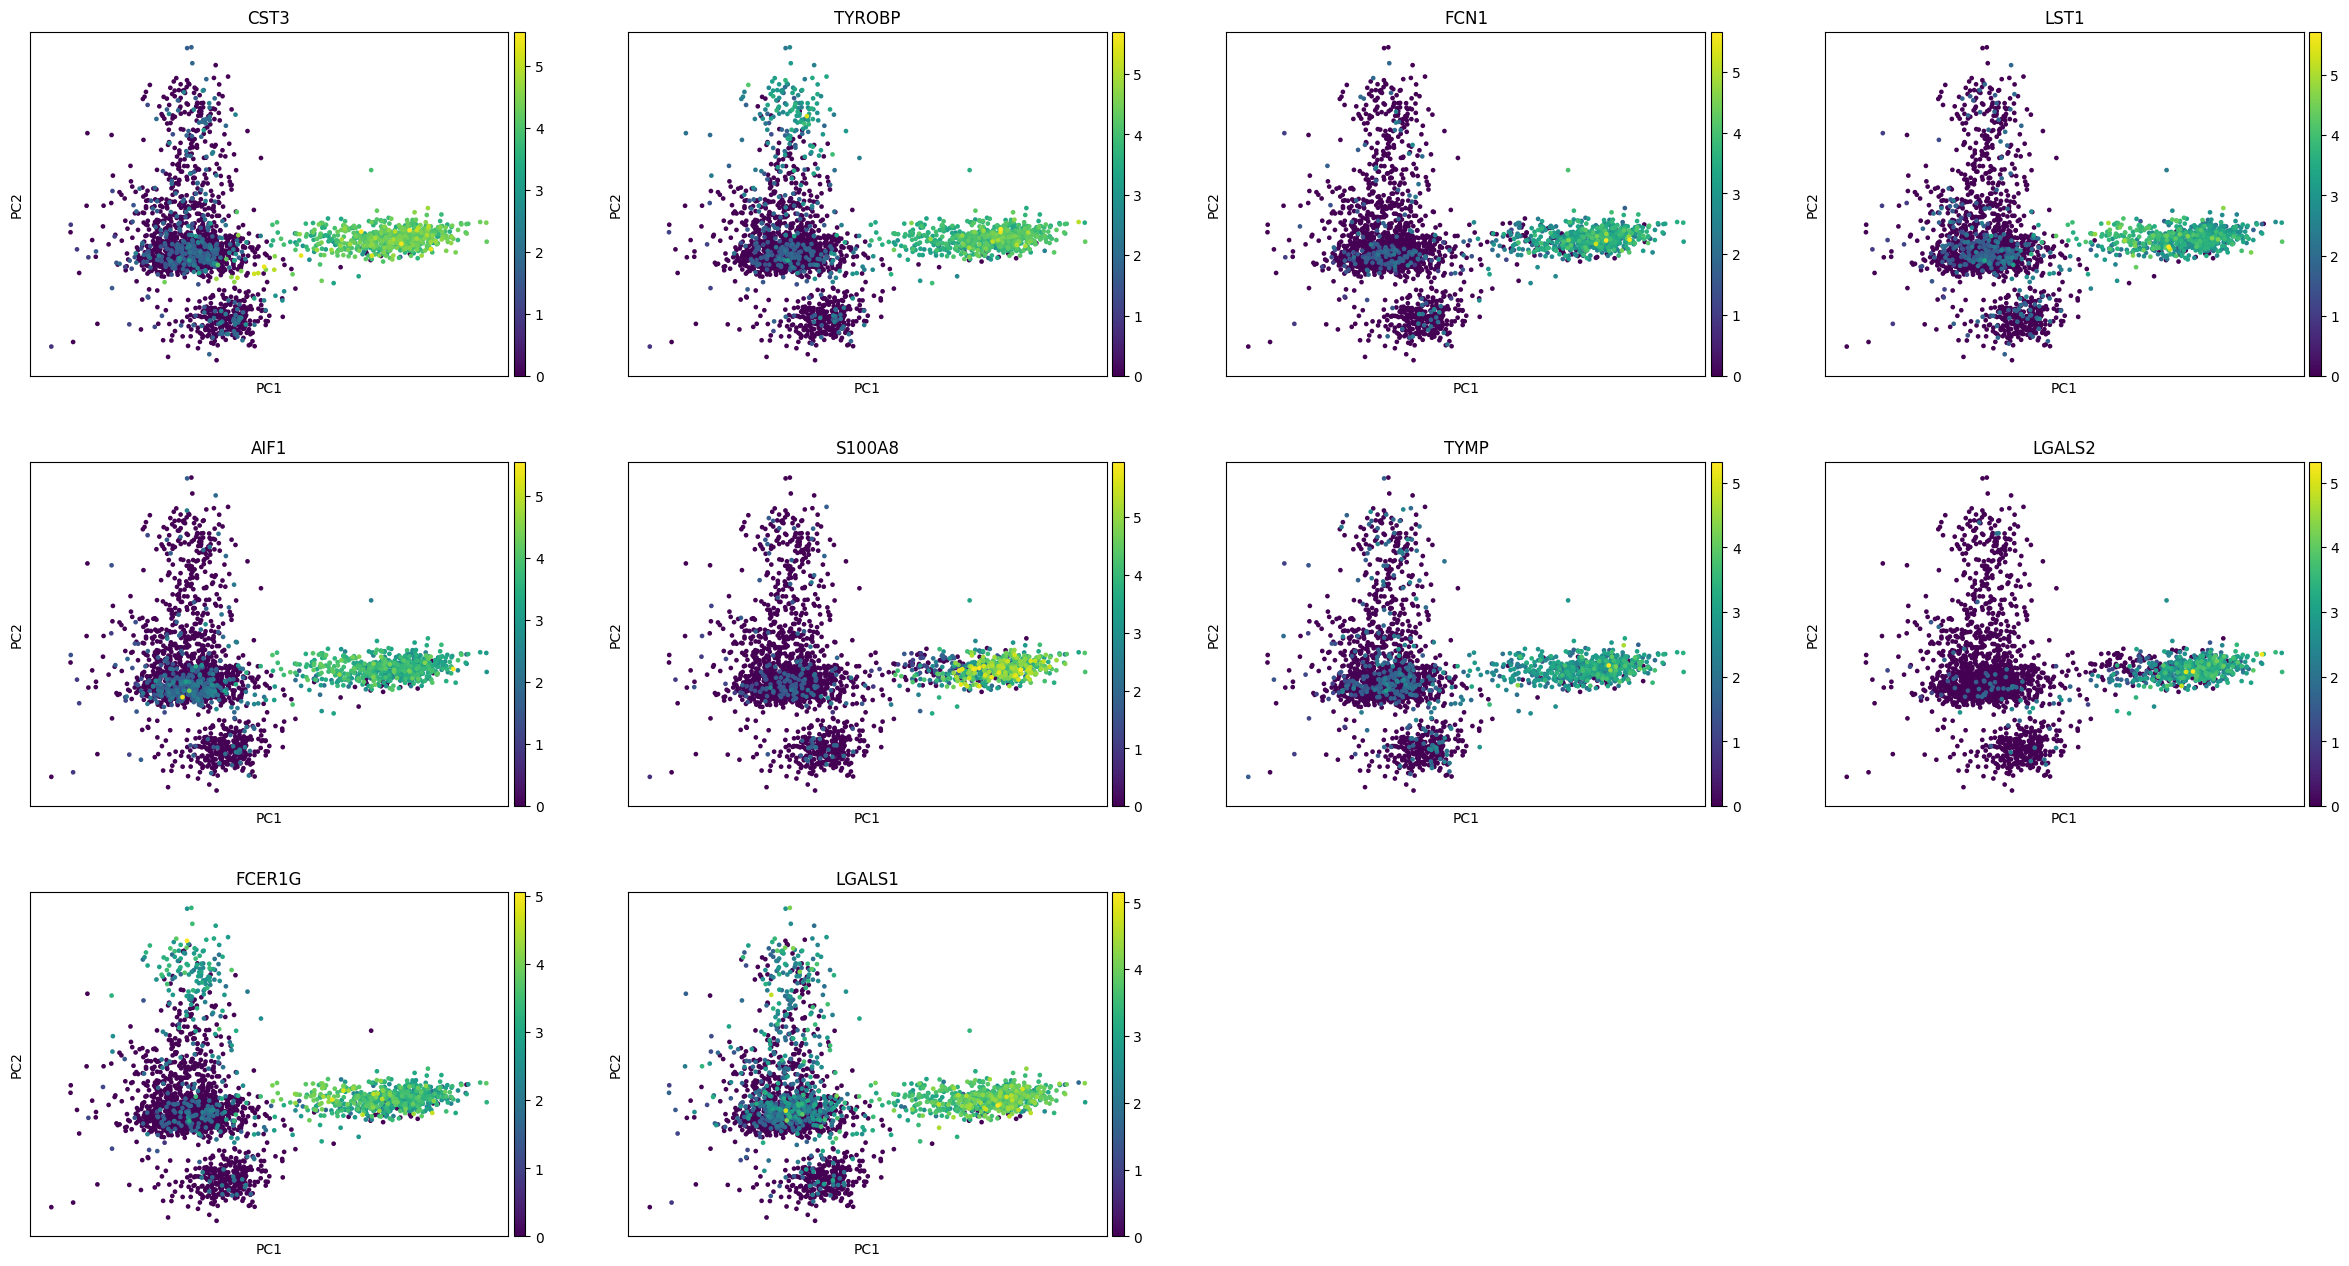

In [29]:
sc.pl.pca(adata, color=top_pc1_genes['genes'])

🔹 PCA reduces the dimensionality of the data while ranking the components (PCs) that explain the most variation. Each PCA component represents specific variations in the dataset, and some components carry more information than others. Therefore, examining the variance contribution of PCA components is a crucial step in understanding which components should be included in the analysis.

#### Elbow Graph

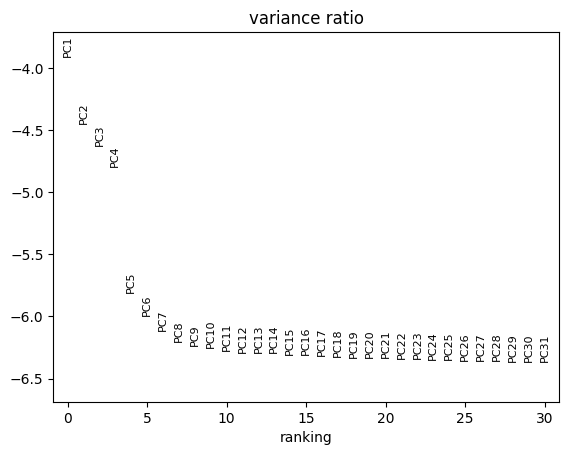

In [30]:
sc.pl.pca_variance_ratio(adata, log=True)

In [31]:
adata

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [33]:
adata.write("data/results_adata.h5ad")

### 🔻 6. Computing the Nearest Neighbor Graph

The neighborhood graph creates a mathematical structure that defines the distances and connections between cells. This structure plays a critical role in helping us understand how cells are organized in groups (e.g., for clustering).

In [34]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

### 🔻 7. Embedding of the Neighborhood Graph into a Low-Dimensional Space

UMAP (Uniform Manifold Approximation and Projection)[(McInnes et al., 2018),](https://arxiv.org/abs/1802.03426) is an algorithm used for dimensionality reduction, designed to project high-dimensional data into a low-dimensional space. Its goal is to group similar cells or data points closer together, thereby preserving the local structure of the data. However, techniques like UMAP and t-SNE are excellent at maintaining local relationships but may not always reflect the global structure accurately. Therefore, while these visualization tools are helpful for understanding the general structure of the data, further analysis is required to derive biological insights before making conclusions.

In [35]:
sc.tl.umap(adata)

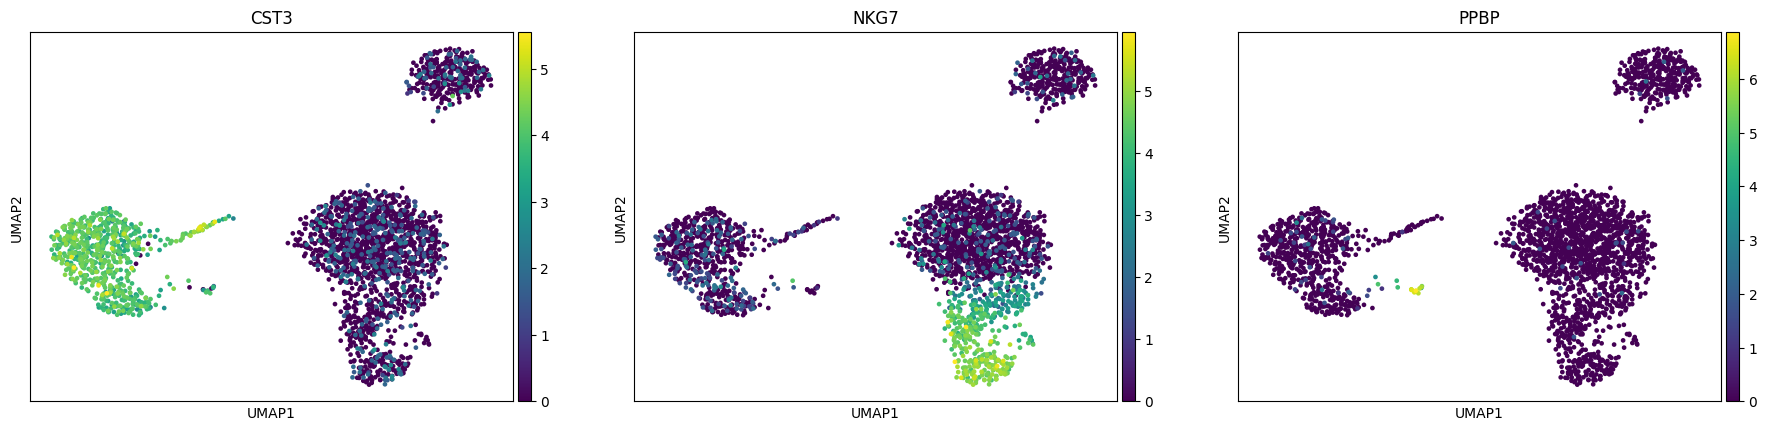

In [36]:
sc.pl.umap(adata, color=["CST3", "NKG7", "PPBP"])

### 🔻 8. Cluster Analysis of the Neighborhood Graph

**The Leiden** clustering method is used to create groups of cells based on their similarities during data analysis. This approach, which optimizes modularity to detect communities, is recommended by Seurat and many other analysis frameworks [Traag et al. (2019)](https://www.nature.com/articles/s41598-019-41695-z#Sec2) Leiden clustering directly utilizes the **neighborhood graph**, which was previously computed in the neighborhood graph calculation step.

The Leiden clustering algorithm groups cells into modular structures (communities), gathering cells with similar characteristics into the same cluster. This process is particularly effective for accurately classifying cell populations in complex biological data.

In [37]:
sc.tl.leiden(
    adata,
    resolution=1.0,
    random_state=0,
    flavor="igraph",
    n_iterations=2,
    directed=False,
)

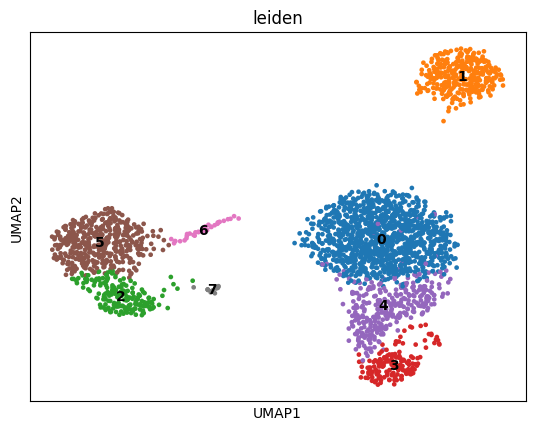

In [38]:
sc.pl.umap(adata, color=["leiden"], legend_loc='on data' )

### 🔻 9. Finding the clusters specific marker genes

To reflect the heterogeneity of our data, identifying marker genes plays a crucial role in uncovering biological significance. By using different statistical methods (e.g.,`t-test`, `wilcoxon`, and `logreg`) gene expression differences between specific cell groups can be examined. The method to be used may vary depending on the type of data and the goal of the analysis.

<div style="border: 2px dashed #0000FF; background-color: #e6f0ff; padding: 15px; margin: 10px 0; border-radius: 10px;">
<b>🦉 Information:</b> Those interested in learning about different methods can refer to the research study on comparing marker gene selection methods for scRNA sequencing data
    <a href="https://genomebiology.biomedcentral.com/articles/10.1186/s13059-024-03183-0/tables/1" target="_blank" style="color: #0000FF; text-decoration: underline;">(Pullin&McCarthy, 2024)</a>.
</div>

#### 🔘 T-test Method

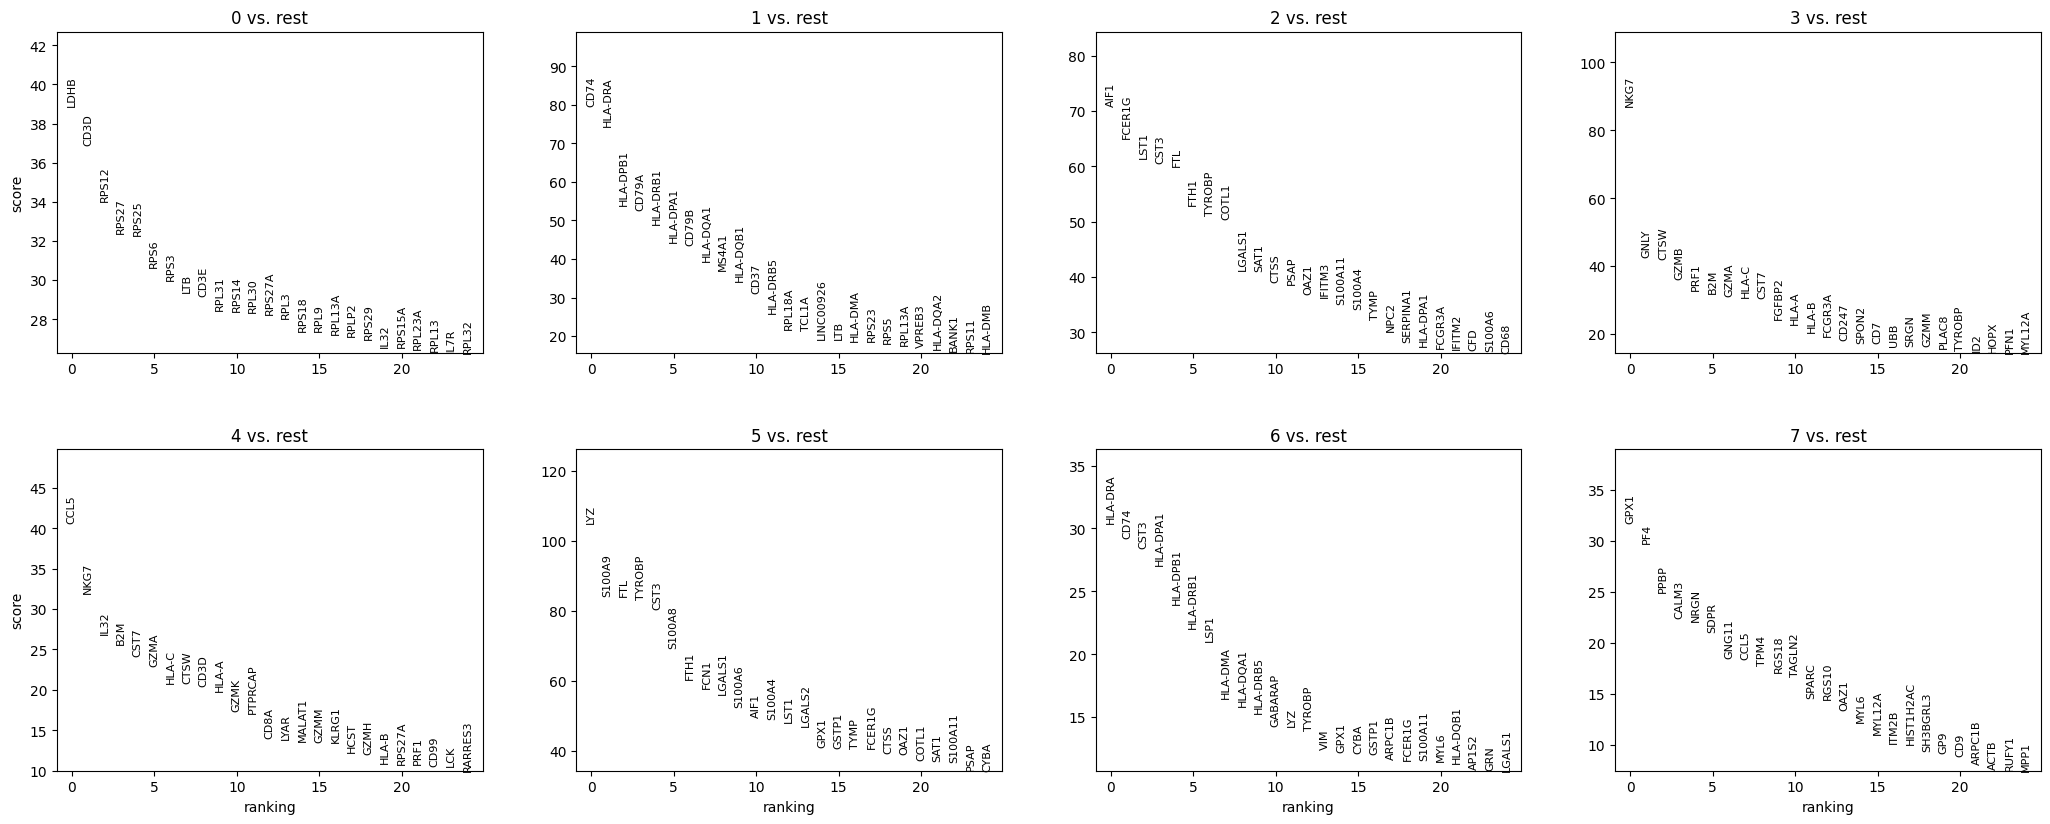

In [39]:
sc.tl.rank_genes_groups(adata, "leiden", method="t-test")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [40]:
sc.settings.verbosity = 2  # reduce the verbosity

#### 🔘 Wilcoxon Method

ranking genes
    finished (0:00:03)


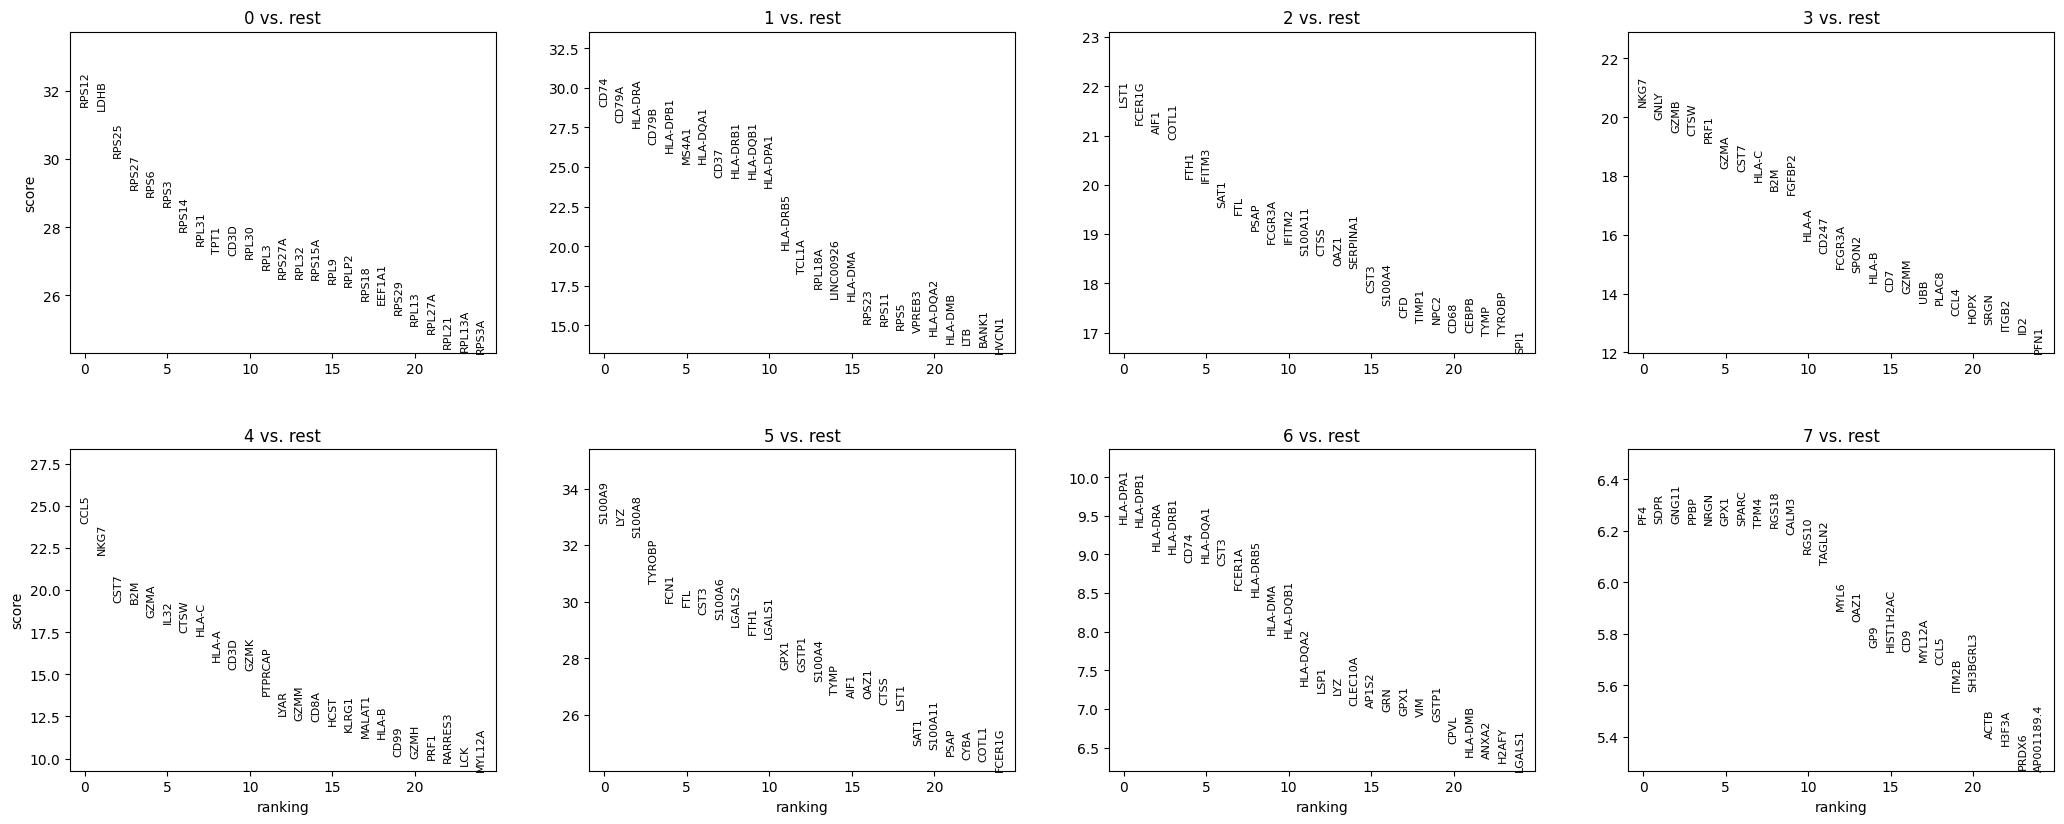

In [41]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

#### 🔘 Logreg Method

ranking genes
    finished (0:00:08)


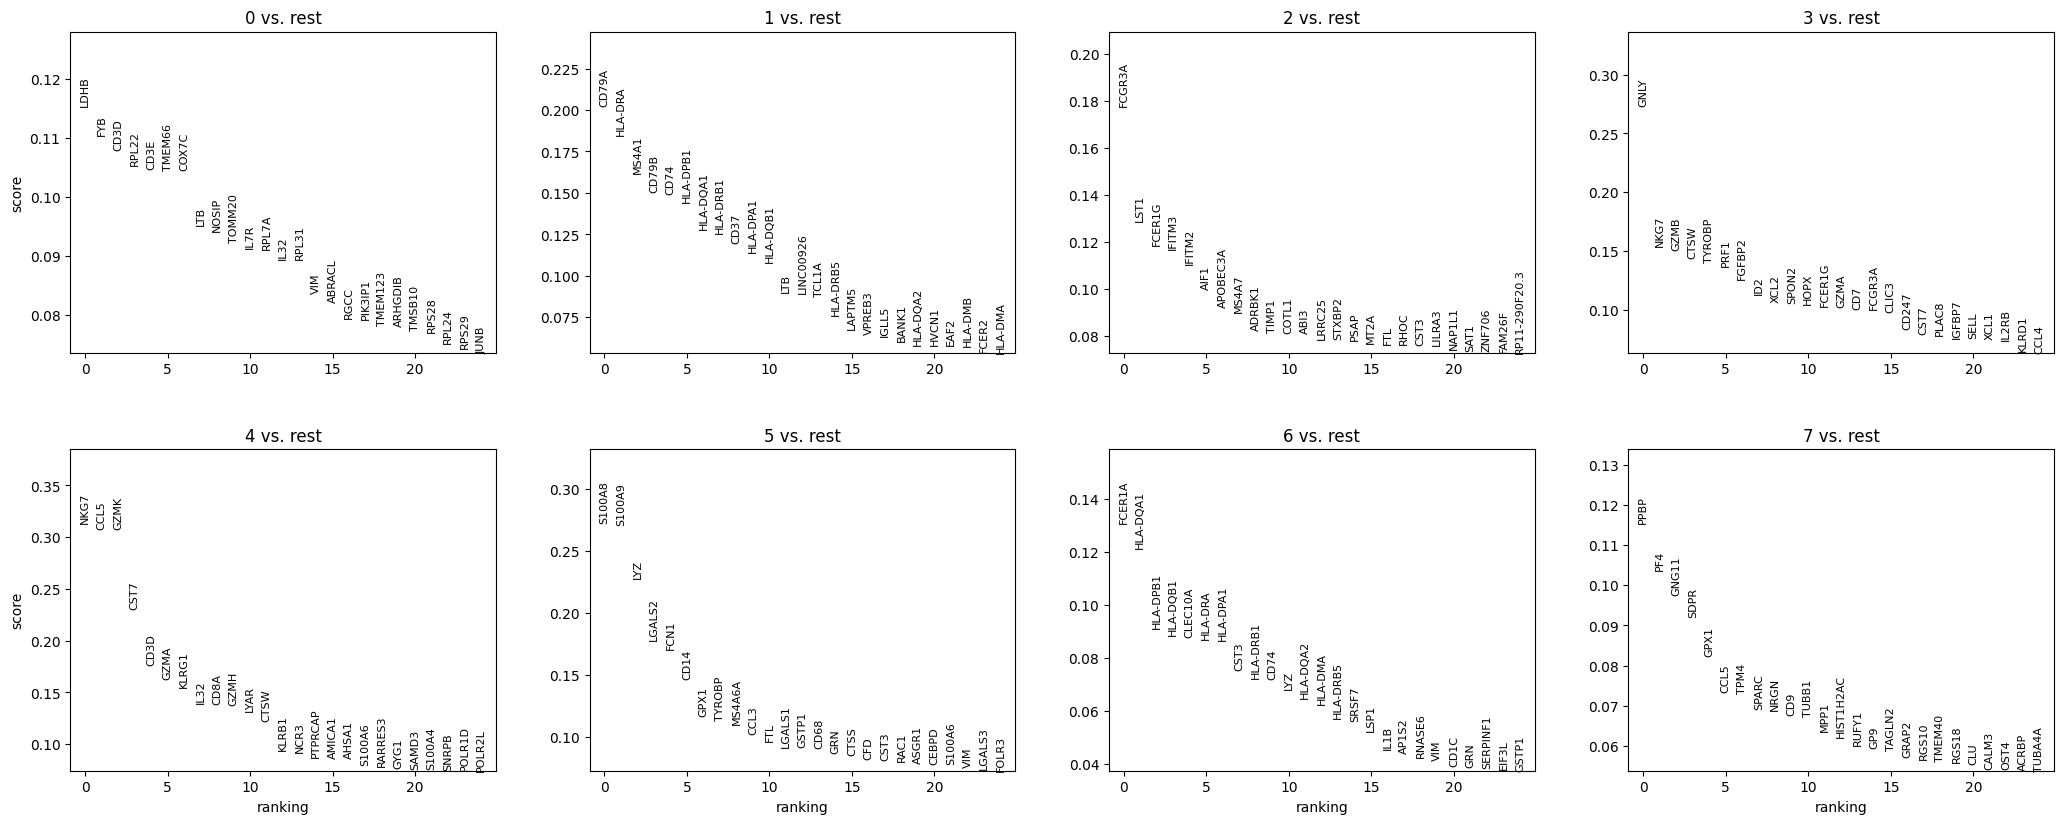

In [42]:
sc.tl.rank_genes_groups(adata, "leiden", method="logreg", max_iter=1000)
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [43]:
pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(10)

,0,1,2,3,4,5,6,7
0,LDHB,CD79A,FCGR3A,GNLY,NKG7,S100A8,FCER1A,PPBP
1,FYB,HLA-DRA,LST1,NKG7,CCL5,S100A9,HLA-DQA1,PF4
2,CD3D,MS4A1,FCER1G,GZMB,GZMK,LYZ,HLA-DPB1,GNG11
3,RPL22,CD79B,IFITM3,CTSW,CST7,LGALS2,HLA-DQB1,SDPR
4,CD3E,CD74,IFITM2,TYROBP,CD3D,FCN1,CLEC10A,GPX1
5,TMEM66,HLA-DPB1,AIF1,PRF1,GZMA,CD14,HLA-DRA,CCL5
6,COX7C,HLA-DQA1,APOBEC3A,FGFBP2,KLRG1,GPX1,HLA-DPA1,TPM4
7,LTB,HLA-DRB1,MS4A7,ID2,IL32,TYROBP,CST3,SPARC
8,NOSIP,CD37,ADRBK1,XCL2,CD8A,MS4A6A,HLA-DRB1,NRGN
9,TOMM20,HLA-DPA1,TIMP1,SPON2,GZMH,CCL3,CD74,CD9


To remind ourselves, the de novo clusters were:

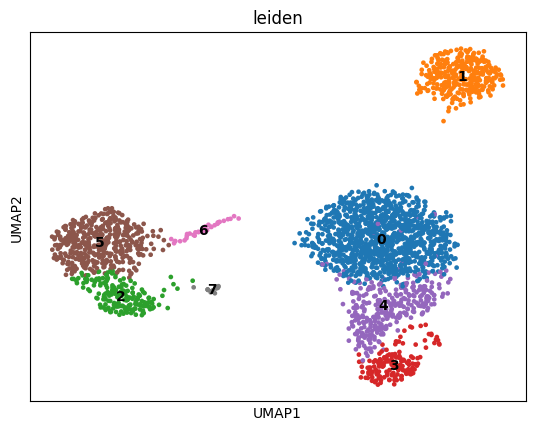

In [44]:
sc.pl.umap(adata, color=["leiden"], legend_loc='on data' )

In [45]:
new_cluster_names = [
    "CD4 T",
    "B",
    "FCGR3A+ Monocytes",
    "NK",
    "CD8 T",
    "CD14+ Monocytes",
    "Dendritic",
    "Megakaryocytes",
]
adata.rename_categories("leiden", new_cluster_names)

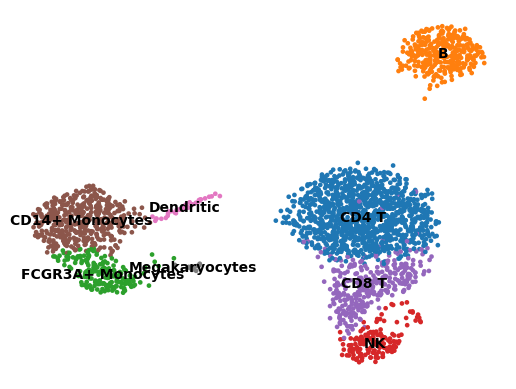

In [46]:
sc.pl.umap(
    adata, color="leiden", legend_loc="on data", title="", frameon=False, save=".pdf"
)

Here's an example list of cell type specific marker genes:

In [47]:
marker_genes = [
    *["IL7R", "CD79A", "MS4A1", "CD8A", "CD8B", "LYZ", "CD14"],
    *["LGALS3", "S100A8", "GNLY", "NKG7", "KLRB1"],
    *["FCGR3A", "MS4A7", "FCER1A", "CST3", "PPBP"],
]

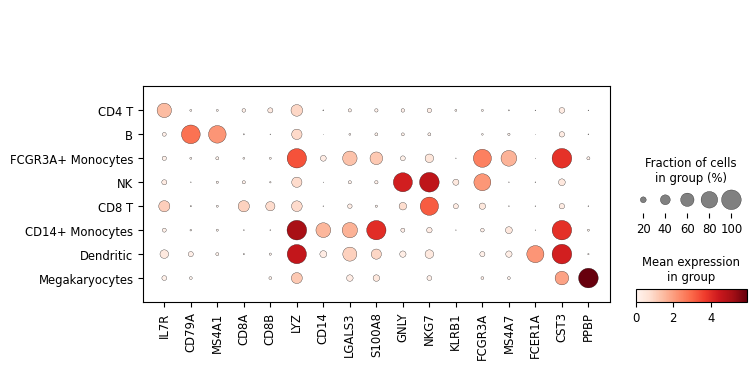

In [48]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden");

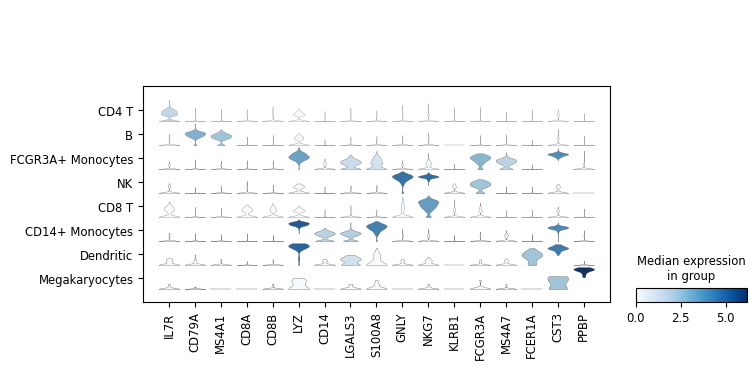

In [49]:
sc.pl.stacked_violin(adata, marker_genes, groupby="leiden");

#### 🔵 Differential Gene Expression Analysis between cell types

The **`rank_genes_groups`** function evaluates the differential gene expression (DGE) differences between `Leiden` clusters. Specifically, it analyzes whether each gene shows higher or lower expression across different cell clusters. Subsequently, the statistical significance of these gene expression differences is determined using the `Wilcoxon` test. In this way, significant and biologically meaningful gene expression changes are identified for each cell cluster.

ranking genes
    finished (0:00:00)


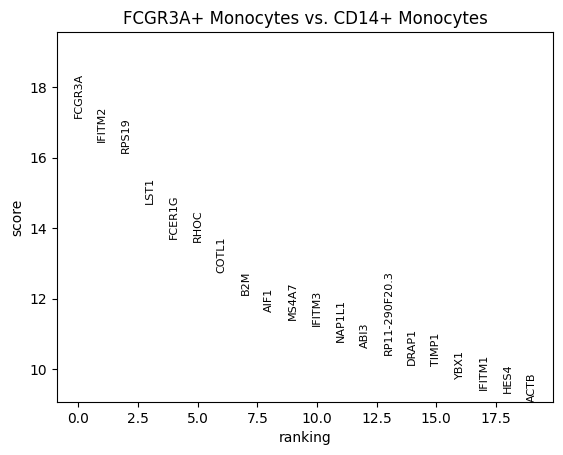

In [50]:
sc.tl.rank_genes_groups(adata, "leiden", groups=["FCGR3A+ Monocytes"], reference="CD14+ Monocytes", method="wilcoxon")
sc.pl.rank_genes_groups(adata, groups=["FCGR3A+ Monocytes"], n_genes=20)

The 8 genes with the highest gene expression levels in *FCGR3A+ monocytes* are shown in a violin plot.

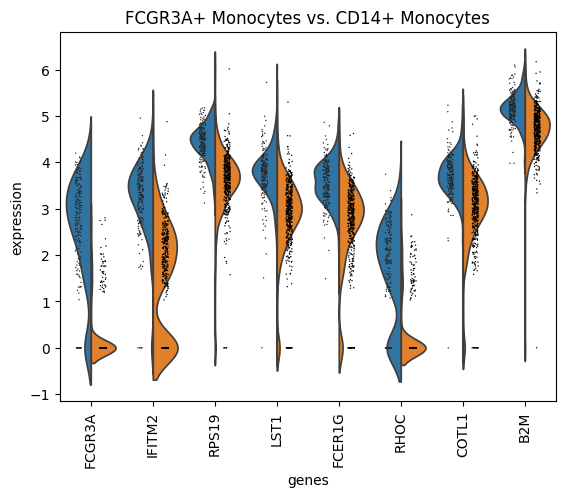

In [51]:
sc.pl.rank_genes_groups_violin(adata, groups="FCGR3A+ Monocytes", n_genes=8)

Let's save our results in `.h5ad` format:

In [52]:
adata.write("./WinterWorkshop_pbmc3k.h5ad", compression="gzip")

In [53]:
adata.raw.to_adata().write("./WinterWorkshop_pbmc3k_withoutX.h5ad")

## 🔶 Reference:
- [Scanpy Tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/)

- [Scanpy visualisation github](https://github.com/mousepixels/sanbomics_scripts/blob/main/Scanpy_intro_pp_clustering_markers.ipynb)

- [Seurat Tutorial](https://satijalab.org/seurat/articles/pbmc3k_tutorial.html)